In [1]:
import pandas as pd
import numpy as np
import string
import nltk
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F
import torch

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Setup NLTK (scarica le risorse)
# nltk.download('stopwords')
# nltk.download('punkt')
# nltk.download('wordnet')

# Inizializza gli strumenti NLP
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [2]:
#!pip install transformers
#pip install torch torchvision torchaudio
# !pip install -U datasets
# !pip install einops
# !pip install sentence-transformers

## Preparazione del DF

In [3]:
# Leggo i file CSV
rev = pd.read_csv("amazon_reviews_Musical_Instruments.csv", on_bad_lines='skip')
item_meta = pd.read_csv("amazon_meta_Musical_Instruments.csv", on_bad_lines='skip')

MIN_REVIEWS_PER_USER = 50
MIN_REVIEWS_PER_ITEM = 15

print(f"Numero di recensioni totali prima del filtro: {len(rev)}")

# Filtro per Utenti Attivi
user_review_counts = rev.groupby('user_id')['parent_asin'].count()
active_users = user_review_counts[user_review_counts >= MIN_REVIEWS_PER_USER].index
rev_filtered_users = rev[rev['user_id'].isin(active_users)]

# Filtro per Item Popolari
item_review_counts = rev_filtered_users.groupby('parent_asin')['user_id'].count()
popular_items = item_review_counts[item_review_counts >= MIN_REVIEWS_PER_ITEM].index
rev_final = rev_filtered_users[rev_filtered_users['parent_asin'].isin(popular_items)]

# Manteniamo solo gli item per cui abbiamo metadati
meta_item_ids = item_meta['parent_asin'].unique()
rev_final = rev_final[rev_final['parent_asin'].isin(meta_item_ids)]

print(f"Numero di recensioni dopo i filtri: {len(rev_final)}")

# Pulizia e rinomina colonne
rev_sample = rev_final[['rating', 'parent_asin', 'user_id']].copy()
rev_sample.rename(columns={'parent_asin': 'itemID', 'user_id': 'userID'}, inplace=True)
rev_sample.reset_index(drop=True, inplace=True)

# RIMOZIONE DEI DATI DUPLICATI
print(f"\nDimensioni prima della rimozione duplicati: {rev_sample.shape[0]}")
rev_sample.drop_duplicates(subset=['userID', 'itemID'], inplace=True)
rev_sample.reset_index(drop=True, inplace=True)
print(f"Dimensioni dopo la rimozione duplicati: {rev_sample.shape[0]}")

item_meta.rename(columns={'parent_asin': 'itemID'}, inplace=True)
item_features = item_meta[['itemID', 'title', 'description']].copy()
# Gestiamo valori mancanti
item_features.fillna({'title': '', 'description': ''}, inplace=True)


# Uniamo i dati delle recensioni con i metadati degli item
df_content = pd.merge(rev_sample, item_features, on='itemID', how='left')
df_content.dropna(subset=['title', 'description'], inplace=True) # Rimuoviamo righe dove i metadati non sono stati trovati

# Statistiche finali sul dataset unito
print(f"Numero finale di utenti unici: {df_content['userID'].nunique()}")
print(f"Numero finale di item unici: {df_content['itemID'].nunique()}")
print(f"Dimensioni finali del dataframe: {df_content.shape}")

display(df_content.head())

Numero di recensioni totali prima del filtro: 3017439
Numero di recensioni dopo i filtri: 3838

Dimensioni prima della rimozione duplicati: 3838
Dimensioni dopo la rimozione duplicati: 3271
Numero finale di utenti unici: 491
Numero finale di item unici: 146
Dimensioni finali del dataframe: (3271, 5)


,rating,itemID,userID,title,description
0,5.0,B000RNB720,AG3S4FROO422V5KP7DJCBXVUQLJQ,Truetone 1 Spot Combo Pack,['Bigger is not always better. At a fraction o...
1,5.0,B0BCK6L7S5,AG3S4FROO422V5KP7DJCBXVUQLJQ,"Donner Guitar Delay Pedal, Yellow Fall Analog ...",[]
2,5.0,B00RVE9X06,AG3S4FROO422V5KP7DJCBXVUQLJQ,KIRLIN Cable IWB-202BFGL-20/BR 20-Feet Premium...,['Kirlin Cable IWB-202BFGL-20/BR - 20 feet - S...
3,5.0,B0BT855NFQ,AG3S4FROO422V5KP7DJCBXVUQLJQ,Fender Rumble 40 V3 Bass Amplifier,['From the company that invented the electric ...
4,5.0,B015JTEBN8,AG3S4FROO422V5KP7DJCBXVUQLJQ,"Samson Microphone Stand, Black (SAMK10)","['The Samson MK10 is perfect for the stage, st..."


## Processamento testuale con Natural Language Processing

In [4]:
# Funzione per pulire e preparare il testo (invariata)
def preprocess_text(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()    # uso str() in questo modo se un un numero finisce dentro viene convertito in stringa, così non da errore
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

# Applica la funzione e combina title e description dell'item per un contenuto ricco
df_content['title_clean'] = df_content['title'].apply(preprocess_text)
df_content['description_clean'] = df_content['description'].apply(preprocess_text)

# Usiamo una combinazione di titolo e descrizione per le feature
df_content['content_clean'] = df_content['title_clean'] + ' ' + df_content['description_clean']

# Rimuoviamo colonne intermedie per pulizia
df_final = df_content[['userID', 'itemID', 'rating', 'content_clean']].copy()

display(df_final.head())

,userID,itemID,rating,content_clean
0,AG3S4FROO422V5KP7DJCBXVUQLJQ,B000RNB720,5.0,truetone 1 spot combo pack bigger always bette...
1,AG3S4FROO422V5KP7DJCBXVUQLJQ,B0BCK6L7S5,5.0,donner guitar delay pedal yellow fall analog d...
2,AG3S4FROO422V5KP7DJCBXVUQLJQ,B00RVE9X06,5.0,kirlin cable iwb202bfgl20br 20feet premium plu...
3,AG3S4FROO422V5KP7DJCBXVUQLJQ,B0BT855NFQ,5.0,fender rumble 40 v3 bass amplifier company inv...
4,AG3S4FROO422V5KP7DJCBXVUQLJQ,B015JTEBN8,5.0,samson microphone stand black samk10 samson mk...


## Bag of Words e KNN

In [5]:
#Creazione vocabolario globale
print("Creazione del vocabolario BoW globale...")
# Prendi tutti i testi unici da tutti gli item
all_item_texts = df_final.drop_duplicates(subset=['itemID'])['content_clean']

# Crea e addestra il vectorizer una sola volta
# max_features limita la dimensione del vocabolario alle 5000 parole più frequenti
global_vectorizer = CountVectorizer(max_features=5000, stop_words='english', min_df=2)
global_vectorizer.fit(all_item_texts)

print(f"Vocabolario globale creato con {len(global_vectorizer.get_feature_names_out())} parole.")

Creazione del vocabolario BoW globale...
Vocabolario globale creato con 1025 parole.


In [31]:
# --- Modello Content-Based con Bag-of-Words (BoW) e KNN con Hyperparameter Tuning ---

print("Avvio dell'addestramento e valutazione dei modelli BoW per utente con GridSearchCV...\n")
mse_users_bow = []
unique_users = df_final["userID"].unique()
# Dizionario per salvare i parametri ottimali per ogni utente
bow_user_best_params = {}

# Istanziamo il vectorizer fuori dal loop
vectorizer = CountVectorizer()

# qua per cambiare user id
user_id_esempio = "AHHJZCFUMYNQ4M2VAYCDX537ZBRQ"
predictions_example_bow = None
item_titles = df_content[['itemID', 'title']].drop_duplicates().set_index('itemID')

for user_id in tqdm(unique_users, desc="Addestramento modelli BoW per utente"):
    # Filtra i dati per l'utente corrente
    user_data = df_final[df_final['userID'] == user_id]

    # Salta utenti con troppo poche recensioni per una CV significativa
    if len(user_data) < 4:
        continue

    try:
        # Dividi i dati
        train_texts, test_texts, y_train, y_test, train_item_ids, test_item_ids = train_test_split(
            user_data['content_clean'],
            user_data['rating'],
            user_data['itemID'],
            test_size=0.25,
            random_state=42,
            shuffle=True
        )

        if train_texts.empty or test_texts.empty:
            continue

        # Vettorizzazione
        X_train = global_vectorizer.transform(train_texts)
        X_test = global_vectorizer.transform(test_texts)
        
        if X_train.shape[0] < 2: # KFold richiede almeno 2 campioni per lo split
            continue

        
        # Definisci i parametri per la Cross-Validation
        cv_folds = min(3, X_train.shape[0])
        
        # Calcola la dimensione del set di addestramento più piccolo nella CV
        n_samples = X_train.shape[0]
        largest_test_set_size = (n_samples + cv_folds - 1) // cv_folds
        n_samples_in_cv_train = n_samples - largest_test_set_size
        
        if n_samples_in_cv_train == 0:
            continue

        # Definisci la griglia di iperparametri in modo sicuro
        k_values = [k for k in [3, 5, 7] if k <= n_samples_in_cv_train]
        if not k_values:
            k_values = [n_samples_in_cv_train]
            
        param_grid = {'n_neighbors': k_values,
                      'metric': ['cosine', 'euclidean']}

        # Inizializza e addestra GridSearchCV
        grid_search = GridSearchCV(
            estimator=KNeighborsRegressor(),
            param_grid=param_grid,
            scoring='neg_mean_squared_error',
            cv=cv_folds,
            n_jobs=-1,
            error_score=0 # Assegna 0 ai fold che falliscono, silenziando i warning
        )
        grid_search.fit(X_train, y_train)

        # Salviamo i migliori parametri trovati per questo utente
        bow_user_best_params[user_id] = grid_search.best_params_
        
        best_model = grid_search.best_estimator_
        

        # 8. Valuta il modello con i parametri ottimali
        y_pred = best_model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mse_users_bow.append((user_id, mse))

        if user_id == user_id_esempio:
            predictions_example_bow = pd.DataFrame({
                'itemID': test_item_ids,
                'rating_reale': y_test,
                'rating_predetto': np.round(y_pred, 2)
            })
            titles_map = item_titles.to_dict()['title']
            predictions_example_bow['title'] = predictions_example_bow['itemID'].map(titles_map)
            print(f"\nIperparametri ottimali per utente {user_id_esempio} (BoW): {grid_search.best_params_}")


    except (ValueError, IndexError):
        continue


Avvio dell'addestramento e valutazione dei modelli BoW per utente con GridSearchCV...



Addestramento modelli BoW per utente:  79%|█████████████████████████████████▎        | 390/491 [00:10<00:01, 77.18it/s]


Iperparametri ottimali per utente AHHJZCFUMYNQ4M2VAYCDX537ZBRQ (BoW): {'metric': 'cosine', 'n_neighbors': 3}


Addestramento modelli BoW per utente: 100%|██████████████████████████████████████████| 491/491 [00:11<00:00, 42.03it/s]


In [32]:
# --- RISULTATI FINALI ---
print("\n--- Performance Medie dei Modelli Content-Based (BoW) ---")
if mse_users_bow:
    mse_values_bow = [mse for user, mse in mse_users_bow]
    average_mse = np.mean(mse_values_bow)
    average_rmse = np.sqrt(average_mse)
    print(f"MSE medio sugli utenti: {average_mse:.4f}")
    print(f"RMSE medio sugli utenti: {average_rmse:.4f}")
    print(f"Modelli valutati con successo per {len(mse_values_bow)} utenti su {len(unique_users)}.")
else:
    print("Nessun utente aveva abbastanza dati per addestrare e valutare un modello.")

# --- Stampa dell'output dettagliato per l'utente di esempio (BoW) ---
print(f"\n\n--- Esempio di Predizione Rating (BoW) per l'utente: {user_id_esempio} ---")
if predictions_example_bow is not None:
    print("Il modello BoW è stato addestrato sugli altri item valutati da questo utente.")
    print("Qui vediamo come ha predetto i rating per gli item nel suo set di test:\n")
    display(predictions_example_bow[['title', 'rating_reale', 'rating_predetto']])
else:
    print("Non è stato possibile generare un esempio BoW per questo utente.")


--- Performance Medie dei Modelli Content-Based (BoW) ---
MSE medio sugli utenti: 1.0970
RMSE medio sugli utenti: 1.0474
Modelli valutati con successo per 354 utenti su 491.


--- Esempio di Predizione Rating (BoW) per l'utente: AHHJZCFUMYNQ4M2VAYCDX537ZBRQ ---
Il modello BoW è stato addestrato sugli altri item valutati da questo utente.
Qui vediamo come ha predetto i rating per gli item nel suo set di test:



,title,rating_reale,rating_predetto
2672,Musiclily Pro 6 inline Guitar Locking Tuners S...,1.0,5.00
2676,Fender Tex-Mex Strat Pickups,4.0,4.67


<h>Funzione creazione top 10 item raccomandati con bow e knn </h>

In [7]:
# Dizionario che fungerà da cache per i modelli addestrati per ogni utente
bow_user_models_cache = {}

def generate_top_k_recommendations_bow_optimized(user_id, df, params_cache, top_k=10):
    """
    Genera raccomandazioni per un utente usando un modello BoW+KNN.
    La funzione è ottimizzata per:
    1. Usare un vectorizer globale pre-addestrato.
    2. Mettere in cache i modelli KNN addestrati per ogni utente, evitando di ri-addestrarli.
    """
    model = bow_user_models_cache.get(user_id)

    # Se il modello per l'utente non è in cache, lo addestriamo
    if model is None:
        user_params = params_cache.get(user_id, {})
        
        if user_params:
            print(f"-> Parametri ottimali per {user_id} trovati: {user_params}. Addestramento in corso...")
        else:
            print(f"-> Parametri ottimali non trovati per {user_id}. Uso default. Addestramento in corso...")
        
        # Imposta parametri di fallback nel caso l'utente non fosse nel dizionario
        default_params = {'metric': 'cosine', 'n_neighbors': 5}
        # Unisce i default con quelli specifici dell'utente (quelli dell'utente hanno la priorità)
        final_params = {**default_params, **user_params}
        
        user_data = df[df['userID'] == user_id]
        if len(user_data) < 2:
            return f"Dati insufficienti per l'utente {user_id}.", None

        train_texts = user_data['content_clean']
        y_train = user_data['rating'].values
        X_train = global_vectorizer.transform(train_texts)

        # Controllo di sicurezza: n_neighbors non può essere > del n. di campioni
        n_samples = X_train.shape[0]
        final_params['n_neighbors'] = min(final_params['n_neighbors'], n_samples)
        
        # Crea il modello con i parametri finali (ottimali o di default)
        model = KNeighborsRegressor(**final_params)
        model.fit(X_train, y_train)
        
        bow_user_models_cache[user_id] = model
        print(f"-> Modello per l'utente {user_id} addestrato e salvato in cache.")
    else:
        print(f"-> Modello per l'utente {user_id} trovato nella cache. Salto l'addestramento.")

    # Identificazione degli item candidati
    items_rated_by_user = set(df[df['userID'] == user_id]['itemID'])
    all_items_df = df.drop_duplicates(subset=['itemID'])
    candidate_items_df = all_items_df[~all_items_df['itemID'].isin(items_rated_by_user)]

    if candidate_items_df.empty:
        return "L'utente ha già valutato tutti gli item del catalogo.", None

    candidate_texts = candidate_items_df['content_clean']
    candidate_item_ids = candidate_items_df['itemID'].values
    
    # Vettorizzazione e Predizione
    X_candidates = global_vectorizer.transform(candidate_texts)
    predicted_ratings = model.predict(X_candidates)

    # Creazione della lista di raccomandazioni
    recommendations = pd.DataFrame({
        'itemID': candidate_item_ids,
        'predicted_rating': predicted_ratings
    })
    
    titles_map = item_titles.to_dict()['title']
    recommendations['title'] = recommendations['itemID'].map(titles_map)
    
    top_k_recommendations = recommendations.sort_values(by='predicted_rating', ascending=False).head(top_k)
    
    user_rated_items = df[df['userID'] == user_id][['itemID', 'rating']].copy()

    user_rated_items['title'] = user_rated_items['itemID'].map(titles_map)

    user_rated_items = user_rated_items[['itemID', 'title', 'rating']]
    
    return user_rated_items, top_k_recommendations


#Esempio di utilizzo
print(f"\n\n--- Generazione Raccomandazioni (BoW Ottimizzato) per l'utente: {user_id_esempio} ---")

user_rated_items_bow, top_10_recs_bow = generate_top_k_recommendations_bow_optimized(
    user_id_esempio, 
    df_final, 
    params_cache=bow_user_best_params, # Passiamo il dizionario
    top_k=10
)

if top_10_recs_bow is not None:
    print("\nItem già valutati dall'utente (usati per l'addestramento):")
    display(user_rated_items_bow[['title', 'rating']].head())
    
    print("\nItem raccomandati con BoW (ordinati per rating predetto):")
    display(top_10_recs_bow[['title', 'predicted_rating']])
else:
    print(user_rated_items_bow)



--- Generazione Raccomandazioni (BoW Ottimizzato) per l'utente: AHHJZCFUMYNQ4M2VAYCDX537ZBRQ ---
-> Parametri ottimali per AHHJZCFUMYNQ4M2VAYCDX537ZBRQ trovati: {'metric': 'cosine', 'n_neighbors': 3}. Addestramento in corso...
-> Modello per l'utente AHHJZCFUMYNQ4M2VAYCDX537ZBRQ addestrato e salvato in cache.

Item già valutati dall'utente (usati per l'addestramento):


,title,rating
2671,"Fender Deluxe Locking Staggered Guitar Tuners,...",5.0
2672,Musiclily Pro 6 inline Guitar Locking Tuners S...,1.0
2673,Fender Vintage-Style Standard Series Stratocas...,4.0
2674,D'Addario Guitar Strings - XL Nickel Electric ...,5.0
2675,Squier Affinity Series Telecaster Electric Gui...,5.0



Item raccomandati con BoW (ordinati per rating predetto):


,title,predicted_rating
69,"Perfektion Pack of six different colors, 1 foo...",5.0
72,D'Addario Accessories Guitar Cable - Guitar Le...,5.0
21,Ernie Ball Ultra-Plush Microfiber Polish Cloth...,5.0
19,"GLS Audio Speaker Cable 1/4"" to 1/4"" - 12 AWG ...",5.0
109,JOYO Distortion Pedal R Series Heavy Metal Dis...,5.0
127,PYLE-PRO Professional Handheld Moving Coil Mic...,5.0
57,D'Addario Guitar Cable - Guitar Patch Cable - ...,5.0
6,"Pyle-Pro Ca, Pyle 1/4"" Audio Cord-¼ to ¼ Inch ...",5.0
77,LyxPro 100 Feet XLR Microphone Cable Balanced ...,5.0
119,Fender American Series String Guides,5.0


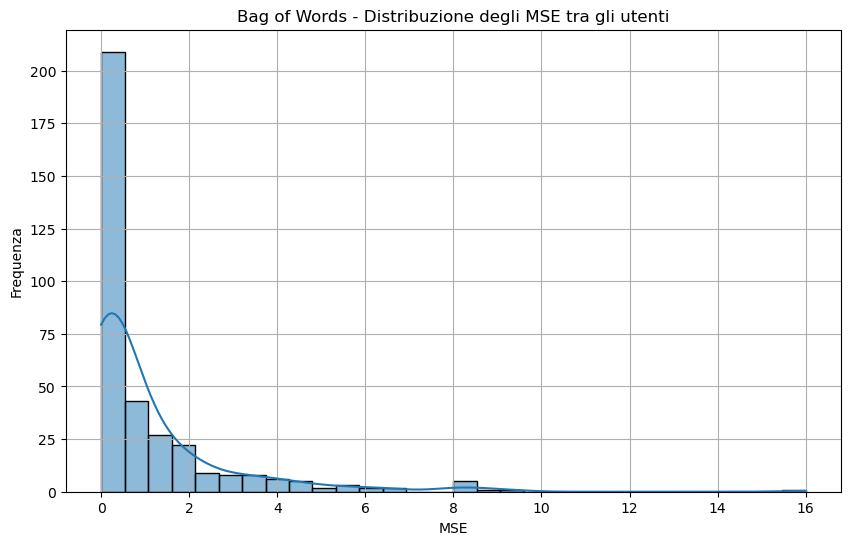

In [34]:
#visualizzazione Visualizzazione: Distribuzione degli MSE
df_mse = pd.DataFrame(mse_users_bow, columns=['user_id', 'mse'])
plt.figure(figsize=(10, 6))
sns.histplot(df_mse['mse'], bins=30, kde=True)
plt.title("Bag of Words - Distribuzione degli MSE tra gli utenti")
plt.xlabel("MSE")
plt.ylabel("Frequenza")
plt.grid(True)
plt.show()

In [9]:
# Ordino la lista per MSE crescente (migliori performance)
mse_users_sorted = sorted(mse_users_bow, key=lambda x: x[1])
top_10_worst = mse_users_sorted[-10:]
print("\nTop 10 utenti con MSE più alto (peggiori performance):")
for user, mse in top_10_worst:
    print(f"User: {user}, MSE: {mse:.4f}")


Top 10 utenti con MSE più alto (peggiori performance):
User: AEMTQ2CMHSRI22GLSIVBRM7FXPAA, MSE: 6.5000
User: AF7L3ET5MOO7VTDNUO5QHQESIM7Q, MSE: 6.5926
User: AGWD6ZH66GXJDVRNQEGY77HOYEJQ, MSE: 8.0000
User: AHTPBPTTB3VBAWDBWIXGAJOZLIGA, MSE: 8.0000
User: AGY6MX3RFBOJEYN3LCCKLOFTVSIA, MSE: 8.1250
User: AHHJZCFUMYNQ4M2VAYCDX537ZBRQ, MSE: 8.2222
User: AFKBZVPC42DGIECDEAOCL57MRAQA, MSE: 8.4444
User: AFCW3I4HL6FLOYFDC4PVL6AE4VLQ, MSE: 9.0000
User: AFZUIWPRDEKD7XPVABNXN764RFEA, MSE: 9.2222
User: AG4EWD2WI4DTYGYZAMOJQ4DPSXGA, MSE: 16.0000


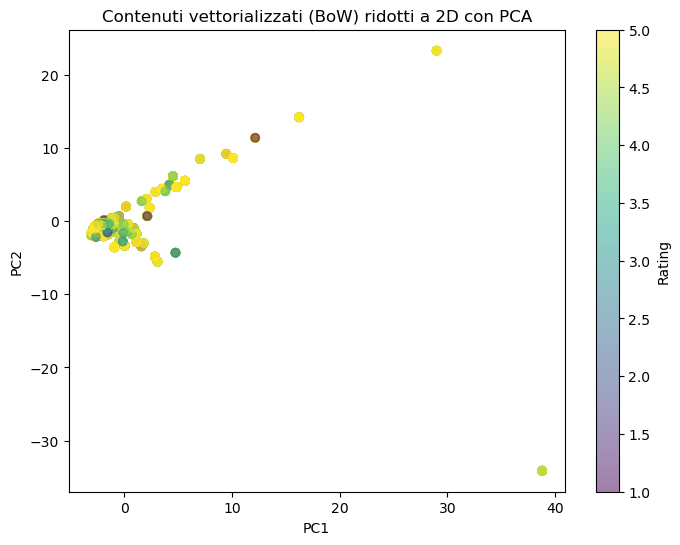

In [10]:
#Vettorizza tutti i testi con Bag of Words.
X_all = vectorizer.fit_transform(df_final["content_clean"])
#Riduce la dimensionalità dei vettori BoW a 2 dimensioni usando PCA.
X_reduced = PCA(n_components=2).fit_transform(X_all.toarray())
#Visualizza i testi come punti in un piano 2D, colorati in base al rating.
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha=0.5, c=df_final["rating"], cmap="viridis")
plt.title("Contenuti vettorializzati (BoW) ridotti a 2D con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Rating")
plt.show()

Cluster → Gruppi di punti vicini → contenuti simili.

Gradienti di colore → Se punti con rating simili sono vicini, allora il contenuto spiega bene il rating.

Se i colori sono sparsi casualmente → il modello content-based potrebbe non essere molto informativo.

## transformers e KNN

In [11]:
# Svuotiamo le cache dei modelli per evitare contaminazioni tra esecuzioni diverse o tra i modelli BoW e Transformer.
print("Svuotamento delle cache dei modelli...")
bow_user_models_cache = {}
transformer_user_models_cache = {}
print("Cache svuotate. Pronto per un nuovo addestramento.")

Svuotamento delle cache dei modelli...
Cache svuotate. Pronto per un nuovo addestramento.


model = AutoModel.from_pretrained('nomic-ai/nomic-embed-text-v1.5')
È un modello Transformer vero basato su architettura tipo BERT, ma ottimizzato per sentence embeddings (simile a Sentence-BERT).

🔹 È stato progettato per semantica → se due frasi parlano della stessa cosa, avranno embedding vicini.

In [12]:
# Per ogni prodotto prendo il contenuto testuale da rev_sample 
meta_sample = df_final.drop_duplicates(subset=["itemID"])[["itemID", "content_clean"]].rename(columns={"content_clean": "text"})
meta_sample

,itemID,text
0,B000RNB720,truetone 1 spot combo pack bigger always bette...
1,B0BCK6L7S5,donner guitar delay pedal yellow fall analog d...
2,B00RVE9X06,kirlin cable iwb202bfgl20br 20feet premium plu...
3,B0BT855NFQ,fender rumble 40 v3 bass amplifier company inv...
4,B015JTEBN8,samson microphone stand black samk10 samson mk...
...,...,...
741,B0BQ2ZB5JX,azor tuner pedal boar chromatic guitar deluxe ...
805,B0BTPB6GRM,caline g008 mini reverb pedal digital guitar p...
811,B0B68Z7PG6,pigtone overdrive distortion guitar effect ped...
817,B07WBZ1SFR,gokko gk22 delay guitar pedal dripping digital...


In [13]:
# Funzione di mean pooling per ottenere un'unica embedding per frase
def mean_pooling(model_output, attention_mask):
    # Estrai le embedding dei token (shape: [batch_size, seq_len, hidden_size])
    token_embeddings = model_output[0]
    # Espandi l'attention mask per poterla applicare alle embedding 
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    # Applica la mask, somma solo i token validi e dividi per il numero di token non-padding (media pesata)
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# Carica il tokenizer del modello pre-addestrato
# nomic-ai/nomic-embed-text-v1.5
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2", trust_remote_code=True)

# Carica il modello pre-addestrato
model = AutoModel.from_pretrained("sentence-transformers/all-MiniLM-L6-v2", trust_remote_code=True)
model.eval()
all_texts = meta_sample["text"].tolist()

# Definisci la dimensione dei batch
BATCH_SIZE = 32
all_embeddings = []

# Ciclo sui testi in batch
for i in tqdm(range(0, len(all_texts), BATCH_SIZE), desc="Generazione Embeddings"):
    batch_texts = all_texts[i:i + BATCH_SIZE]
    batch_dict = tokenizer(batch_texts, padding=True, truncation=True, return_tensors='pt')

    with torch.no_grad():
        # Ottieni l'output del modello (token embeddings)
        model_output = model(**batch_dict)

    # Applica il mean pooling per ottenere una embedding per ogni frase
    batch_embeddings = mean_pooling(model_output, batch_dict['attention_mask'])

    # Normalizza le embedding (norma L2 = 1) per facilitarne l'uso in similarità
    batch_embeddings = F.normalize(batch_embeddings, p=2, dim=1)
    all_embeddings.append(batch_embeddings.cpu())
# Concatena tutte le embedding in un unico tensor finale
embeddings = torch.cat(all_embeddings, dim=0)

# Stampa la shape finale delle embedding
print(f"\nEmbedding shape: {embeddings.shape}")


Generazione Embeddings: 100%|████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.04it/s]


Embedding shape: torch.Size([146, 384])


In [14]:
embeddings

tensor([[-0.0403, -0.0404, -0.0407,  ...,  0.0122,  0.0059, -0.1252],
        [-0.1012,  0.0028,  0.0487,  ..., -0.0467,  0.0913, -0.0280],
        [-0.0898,  0.0514, -0.0040,  ..., -0.0479, -0.0264, -0.0351],
        ...,
        [-0.0815, -0.0104,  0.0124,  ..., -0.1092,  0.0548, -0.1149],
        [-0.1526,  0.0422,  0.0359,  ..., -0.0471,  0.0709, -0.0430],
        [-0.0489, -0.0498, -0.0425,  ...,  0.0194,  0.1181, -0.0475]])

In [15]:
# Crea un DataFrame con gli embedding e itemID:
item_id_to_embedding = pd.Series(embeddings.cpu().numpy().tolist(), index=meta_sample["itemID"])

<h>Allenamento e testing trasformer embedding e KNN </h>

In [16]:
# --- Modello Content-Based con Transformer e KNN con Hyperparameter Tuning ---

print("Avvio della predizione dei rating per utente con Transformer Embeddings e GridSearchCV...")

mse_users_transformer = []
unique_users = df_final["userID"].unique()
transformer_user_best_params = {}

item_titles = df_content[['itemID', 'title']].drop_duplicates().set_index('itemID')
titles_map = item_titles.to_dict()['title']

user_id_esempio_predizione = "AHHJZCFUMYNQ4M2VAYCDX537ZBRQ"
predictions_example = None

for user_id in tqdm(unique_users, desc="Modelli per utente (Transformer)"):
    user_data = df_final[df_final['userID'] == user_id].copy()

    if len(user_data) < 4:
        continue

    try:
        user_item_ids = user_data['itemID'].values
        user_ratings = user_data['rating'].values
        
        if not all(item_id in item_id_to_embedding.index for item_id in user_item_ids):
            continue
        X_user_embeddings = np.array([item_id_to_embedding[item_id] for item_id in user_item_ids])
        
        X_train_emb, X_test_emb, y_train_emb, y_test_emb, train_item_ids, test_item_ids = train_test_split(
            X_user_embeddings, user_ratings, user_item_ids,
            test_size=0.25, random_state=42, shuffle=True
        )

        if X_train_emb.shape[0] < 2: # KFold richiede almeno 2 campioni per lo split
            continue

        
        # Definisci i parametri per la Cross-Validation
        # Il numero di fold non può essere superiore al numero di campioni.
        cv_folds = min(3, X_train_emb.shape[0])


        n_samples = X_train_emb.shape[0]
        # La dimensione del test set più grande è ceil(n_samples / cv_folds)
        largest_test_set_size = (n_samples + cv_folds - 1) // cv_folds
        n_samples_in_cv_train = n_samples - largest_test_set_size
        
        if n_samples_in_cv_train == 0:
            continue

        # Definisci la griglia di iperparametri in modo sicuro
        # n_neighbors non può essere maggiore del numero di campioni su cui si addestra.
        k_values = [k for k in [3, 5, 7] if k <= n_samples_in_cv_train]
        # Se nessun k standard è valido, usa il massimo k possibile (se > 0).
        if not k_values:
            k_values = [n_samples_in_cv_train]
            
        param_grid = {'n_neighbors': k_values,
                      'metric': ['cosine', 'euclidean']}

        # Inizializza e addestra GridSearchCV
        # error_score=0 assegna un punteggio di 0 ai fold che falliscono, silenziando i warning.
        grid_search_transformer = GridSearchCV(
            estimator=KNeighborsRegressor(),
            param_grid=param_grid,
            scoring='neg_mean_squared_error',
            cv=cv_folds,
            n_jobs=-1,
            error_score=0 
        )
        grid_search_transformer.fit(X_train_emb, y_train_emb)

        transformer_user_best_params[user_id] = grid_search_transformer.best_params_
        
        best_model_transformer = grid_search_transformer.best_estimator_
        

        y_pred_emb = best_model_transformer.predict(X_test_emb)
        mse_emb = mean_squared_error(y_test_emb, y_pred_emb)
        mse_users_transformer.append((user_id, mse_emb))

        if user_id == user_id_esempio_predizione:
            predictions_example = pd.DataFrame({
                'itemID': test_item_ids,
                'rating_reale': y_test_emb,
                'rating_predetto': np.round(y_pred_emb, 2)
            })
            predictions_example['title'] = predictions_example['itemID'].map(titles_map)
            print(f"\nIperparametri ottimali per utente {user_id_esempio_predizione} (Transformer): {grid_search_transformer.best_params_}")
            
    except (ValueError, IndexError):
        continue


#Stampa dei risultati aggregati
print("\n--- Performance Medie dei Modelli Content-Based (Transformer Embeddings) ---")
if mse_users_transformer:
    mse_values = [mse for _, mse in mse_users_transformer]
    average_mse_transformer = np.mean(mse_values)
    average_rmse_transformer = np.sqrt(average_mse_transformer)
    print(f"MSE medio sugli utenti (Transformer): {average_mse_transformer:.4f}")
    print(f"RMSE medio sugli utenti (Transformer): {average_rmse_transformer:.4f}")
    print(f"Modelli valutati con successo per {len(mse_users_transformer)} utenti su {len(unique_users)}.")
else:
    print("Nessun utente aveva abbastanza dati.")
    
#Stampa dell'output dettagliato per l'utente di esempio
print(f"\n\n--- Esempio di Predizione Rating per l'utente: {user_id_esempio_predizione} ---")
if predictions_example is not None:
    print("Il modello è stato addestrato sugli altri item valutati da questo utente.")
    print("Qui vediamo come ha predetto i rating per gli item nel suo set di test:\n")
    display(predictions_example[['title', 'rating_reale', 'rating_predetto']])
else:
    print("Non è stato possibile generare un esempio per questo utente (probabilmente pochi dati).")

Avvio della predizione dei rating per utente con Transformer Embeddings e GridSearchCV...


Modelli per utente (Transformer):  81%|█████████████████████████████████████▏        | 397/491 [00:05<00:01, 88.60it/s]


Iperparametri ottimali per utente AHHJZCFUMYNQ4M2VAYCDX537ZBRQ (Transformer): {'metric': 'cosine', 'n_neighbors': 3}


Modelli per utente (Transformer): 100%|██████████████████████████████████████████████| 491/491 [00:06<00:00, 78.49it/s]


--- Performance Medie dei Modelli Content-Based (Transformer Embeddings) ---
MSE medio sugli utenti (Transformer): 1.1282
RMSE medio sugli utenti (Transformer): 1.0622
Modelli valutati con successo per 354 utenti su 491.


--- Esempio di Predizione Rating per l'utente: AHHJZCFUMYNQ4M2VAYCDX537ZBRQ ---
Il modello è stato addestrato sugli altri item valutati da questo utente.
Qui vediamo come ha predetto i rating per gli item nel suo set di test:



,title,rating_reale,rating_predetto
0,Musiclily Pro 6 inline Guitar Locking Tuners S...,1.0,5.00
1,Fender Tex-Mex Strat Pickups,4.0,4.67


<h>Raccomandazione dei top 10 item per un certo user_id, utilizzando gli embedding trasformer e knn</h>

In [17]:

# Definisci le cache all'inizio della cella, assicurandoti che siano vuote
transformer_user_models_cache = {}

# Assicuriamoci che item_titles e la sua mappa siano pronti
item_titles = df_content[['itemID', 'title']].drop_duplicates().set_index('itemID')
titles_map = item_titles.to_dict()['title']

def generate_top_k_recommendations_transformer(user_id, df, item_embeddings, params_cache, top_k=10):
    """
    Genera raccomandazioni Top-K per un utente usando un modello basato su Transformer Embeddings.
    La funzione è ottimizzata per mettere in cache i modelli KNN addestrati per ogni utente.
    """
    model = transformer_user_models_cache.get(user_id)

    # Se il modello per l'utente non è in cache, lo addestriamo
    if model is None:
        user_params = params_cache.get(user_id, {})
        
        if user_params:
            print(f"-> Parametri ottimali Transformer per {user_id} trovati: {user_params}. Addestramento...")
        else:
            print(f"-> Parametri ottimali Transformer non trovati per {user_id}. Uso default. Addestramento...")
            
        default_params = {'metric': 'cosine', 'n_neighbors': 5}
        final_params = {**default_params, **user_params}

        # Dati di training: item che l'utente ha già valutato
        user_data = df[df['userID'] == user_id]
        
        if len(user_data) < 2:
            return f"Dati insufficienti per l'utente {user_id}.", None

        # Recuperiamo gli ID e i rating per il training set
        train_item_ids = user_data['itemID'].values
        y_train = user_data['rating'].values
        
        # Gestiamo il caso in cui un item non abbia un embedding
        valid_train_indices = [i for i, item_id in enumerate(train_item_ids) if item_id in item_embeddings.index]
        if not valid_train_indices:
             return f"Nessun embedding trovato per gli item valutati dall'utente {user_id}.", None
        

        X_train = np.array([item_embeddings[train_item_ids[i]] for i in valid_train_indices])
        y_train = y_train[valid_train_indices]

        # Addestramento del modello KNN
        n_samples = X_train.shape[0]
        # Controllo di sicurezza: n_neighbors non può essere > del n. di campioni
        final_params['n_neighbors'] = min(final_params.get('n_neighbors', 5), n_samples)
        
        model = KNeighborsRegressor(**final_params)
        model.fit(X_train, y_train)
        
        # Salvataggio del modello nella cache
        transformer_user_models_cache[user_id] = model
        print(f"-> Modello Transformer per {user_id} addestrato e salvato in cache.")
    else:
        print(f"-> Modello Transformer per {user_id} trovato in cache. Salto l'addestramento.")

    # Identificazione degli item candidati (non visti dall'utente)
    items_rated_by_user = set(df[df['userID'] == user_id]['itemID'])
    all_items_with_embedding = item_embeddings.index
    candidate_item_ids = [item_id for item_id in all_items_with_embedding if item_id not in items_rated_by_user]

    if not candidate_item_ids:
        return "L'utente ha già valutato tutti gli item del catalogo con embedding.", None

    X_candidates = np.array([item_embeddings[item_id] for item_id in candidate_item_ids])
    predicted_ratings = model.predict(X_candidates)

    # Creazione della lista di raccomandazioni
    recommendations = pd.DataFrame({
        'itemID': candidate_item_ids,
        'predicted_rating': predicted_ratings
    })
    
    recommendations['title'] = recommendations['itemID'].map(titles_map)
    top_k_recommendations = recommendations.sort_values(by='predicted_rating', ascending=False).head(top_k)
    
    # Prepariamo i dati dell'utente per l'output
    user_rated_items = df[df['userID'] == user_id][['itemID', 'rating']].copy()
    user_rated_items['title'] = user_rated_items['itemID'].map(titles_map)
    user_rated_items = user_rated_items[['itemID', 'title', 'rating']]
    
    return user_rated_items, top_k_recommendations








print(f"\n\n--- Top 10 Raccomandazioni (Transformer) per l'utente: {user_id_esempio_predizione} ---")

user_items_transformer, top_10_recs_transformer = generate_top_k_recommendations_transformer(
    user_id_esempio_predizione, 
    df_final, 
    item_id_to_embedding,
    params_cache=transformer_user_best_params,
    top_k=10
)

if top_10_recs_transformer is not None:
    print("\nItem già valutati dall'utente (usati per addestrare il modello Transformer):")
    display(user_items_transformer)
    
    print("\nItem raccomandati (ordinati per rating predetto):")
    display(top_10_recs_transformer[['title', 'predicted_rating']])
else:
    print(user_items_transformer) # Stampa il messaggio di errore



--- Top 10 Raccomandazioni (Transformer) per l'utente: AHHJZCFUMYNQ4M2VAYCDX537ZBRQ ---
-> Parametri ottimali Transformer per AHHJZCFUMYNQ4M2VAYCDX537ZBRQ trovati: {'metric': 'cosine', 'n_neighbors': 3}. Addestramento...
-> Modello Transformer per AHHJZCFUMYNQ4M2VAYCDX537ZBRQ addestrato e salvato in cache.

Item già valutati dall'utente (usati per addestrare il modello Transformer):


,itemID,title,rating
2671,B0BKR2ZM9X,"Fender Deluxe Locking Staggered Guitar Tuners,...",5.0
2672,B07DVX841V,Musiclily Pro 6 inline Guitar Locking Tuners S...,1.0
2673,B0B3VQQ6XY,Fender Vintage-Style Standard Series Stratocas...,4.0
2674,B0BPJ4Q6FJ,D'Addario Guitar Strings - XL Nickel Electric ...,5.0
2675,B07D4QCBX4,Squier Affinity Series Telecaster Electric Gui...,5.0
2676,B0B81FBRNV,Fender Tex-Mex Strat Pickups,4.0
2677,B09PWCF6T9,KLIQ UberTuner-Max - Rechargable Professional ...,5.0
2678,B09M7P8SBH,"Ernie Ball, Super Slinky Electric Guitar Strin...",5.0



Item raccomandati (ordinati per rating predetto):


,title,predicted_rating
0,Truetone 1 Spot Combo Pack,5.0
93,"Jim Dunlop 6554 Dunlop Ultimate Lemon Oil, 4 oz.",5.0
86,"Donner Small Guitar Pedal Board, Mini Effects ...",5.0
81,Gavitt Guitar Wire Cloth-Covered Vintage-Style...,5.0
80,Hosa CPE-118 Right Angle to Right Angle Guitar...,5.0
79,Elixir® Strings 16545 Acoustic Phosphor Bronze...,5.0
72,D'Addario Accessories Guitar Cable - Guitar Le...,5.0
1,"Donner Guitar Delay Pedal, Yellow Fall Analog ...",5.0
65,Elixir Strings 7-String Electric Guitar String...,5.0
62,GLS Audio 12ft Mic Cable Patch Cords - XLR Mal...,5.0


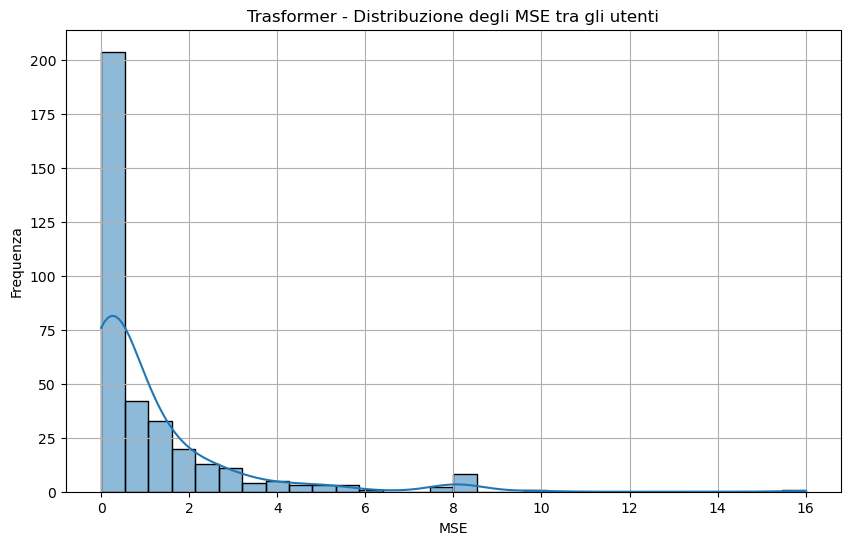

In [33]:
#visualizzazione Visualizzazione: Distribuzione degli MSE
df_mse_trasformer = pd.DataFrame(mse_users_transformer, columns=['user_id', 'mse'])
plt.figure(figsize=(10, 6))
sns.histplot(df_mse_trasformer['mse'], bins=30, kde=True)
plt.title("Trasformer - Distribuzione degli MSE tra gli utenti")
plt.xlabel("MSE")
plt.ylabel("Frequenza")
plt.grid(True)
plt.show()

In [19]:
# Ordino la lista per MSE crescente
mse_users_transformer_sorted = sorted(mse_users_transformer, key=lambda x: x[1])
top_10_worst = mse_users_transformer_sorted[-10:]
print("\nTop 10 utenti con MSE più alto (peggiori performance):")
for user, mse in top_10_worst:
    print(f"User: {user}, MSE: {mse:.4f}")



Top 10 utenti con MSE più alto (peggiori performance):
User: AEDBU4UHNM6F5BEWRO2LY2LGYAJA, MSE: 8.0000
User: AGYK2YYS35CDU2Z77ZQR7L3IAX4Q, MSE: 8.0000
User: AHTPBPTTB3VBAWDBWIXGAJOZLIGA, MSE: 8.0000
User: AELUT73PSKWAQ3D5L6SDD72TCPNA, MSE: 8.1250
User: AGY6MX3RFBOJEYN3LCCKLOFTVSIA, MSE: 8.1250
User: AGXWBFBAKLMJWMQIC25BQF3IU7TQ, MSE: 8.2222
User: AHHJZCFUMYNQ4M2VAYCDX537ZBRQ, MSE: 8.2222
User: AEYFBVNHQB44H2447LLFNYQGZYMQ, MSE: 8.5000
User: AFKBZVPC42DGIECDEAOCL57MRAQA, MSE: 9.7778
User: AG4EWD2WI4DTYGYZAMOJQ4DPSXGA, MSE: 16.0000


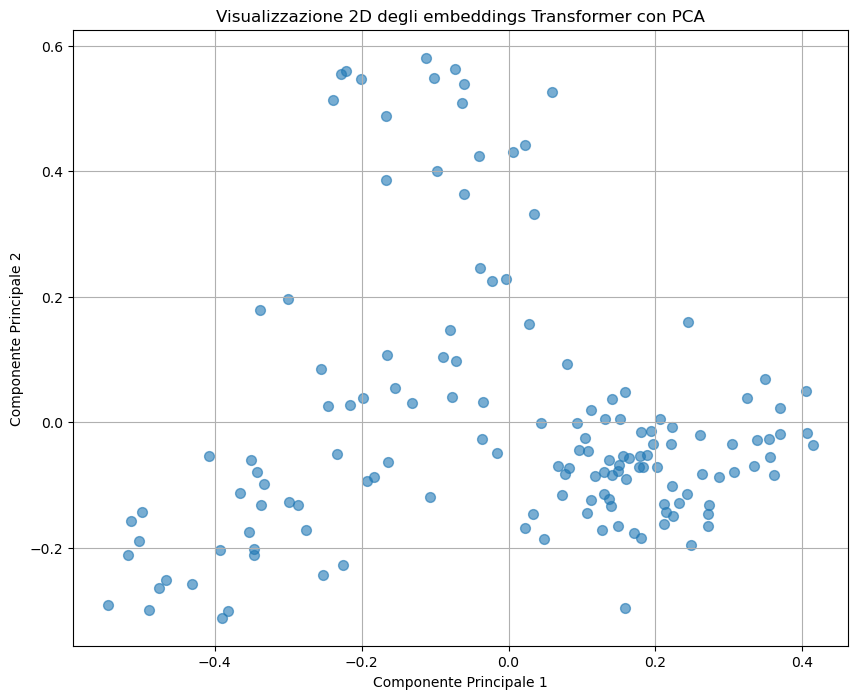

In [20]:
# 1. Applica PCA per ridurre a 2 dimensioni
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings.cpu().numpy())  # se embeddings è tensor PyTorch, convertilo in numpy

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, s=50)
plt.title("Visualizzazione 2D degli embeddings Transformer con PCA")
plt.xlabel("Componente Principale 1")
plt.ylabel("Componente Principale 2")
plt.grid(True)
plt.show()

# Valutazione critica dei risultati ottenuti con le due diverse tecniche di embedding

In [21]:
# mse_users lista del BoW
# average_mse = np.mean(mse_users)
# average_rmse = np.sqrt(average_mse)
# mse_users_transformer altra list
# average_mse_transformer = np.mean(mse_users_transformer)
#average_rmse_transformer

In [22]:
print("--- Performance media BoW ---")
print(f"MSE medio: {average_mse:.4f}")
print(f"RMSE medio: {average_rmse:.4f}")

print("\n--- Performance media Transformer ---")
print(f"MSE medio: {average_mse_transformer:.4f}")
print(f"RMSE medio: {average_rmse_transformer:.4f}")

--- Performance media BoW ---
MSE medio: 1.0970
RMSE medio: 1.0474

--- Performance media Transformer ---
MSE medio: 1.1282
RMSE medio: 1.0622


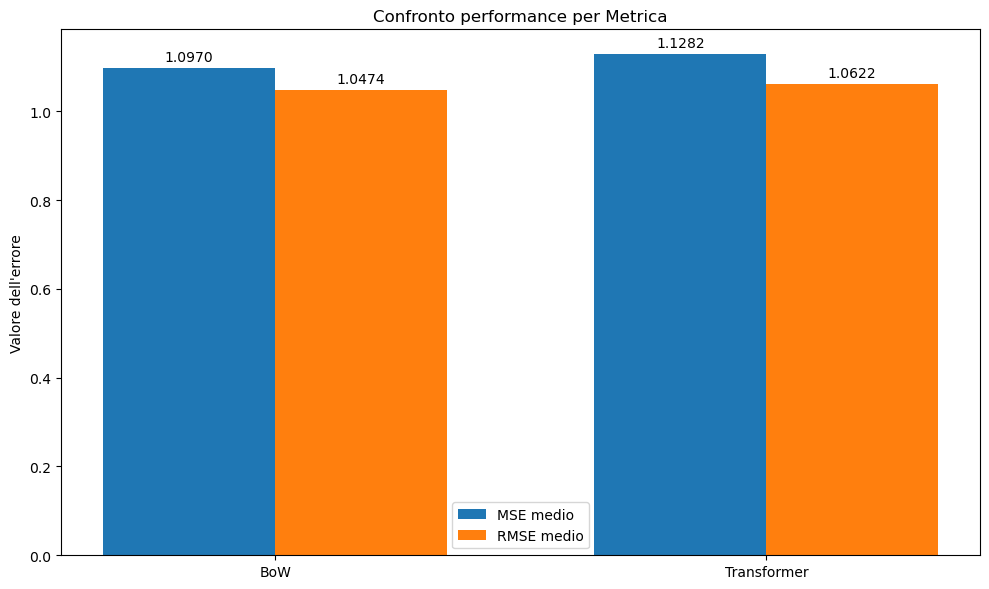

In [23]:
# Dati corretti per il confronto
labels = ['BoW', 'Transformer']
mse_values = [average_mse, average_mse_transformer]
rmse_values = [average_rmse, average_rmse_transformer]

# Creazione di un grafico a barre raggruppate
x = np.arange(len(labels)) 
width = 0.35  # la larghezza delle barre

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, mse_values, width, label='MSE medio')
rects2 = ax.bar(x + width/2, rmse_values, width, label='RMSE medio')

ax.set_ylabel('Valore dell\'errore')
ax.set_title('Confronto performance per Metrica')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Aggiungi i valori sopra le barre
ax.bar_label(rects1, padding=3, fmt='%.4f')
ax.bar_label(rects2, padding=3, fmt='%.4f')

fig.tight_layout()
plt.show()

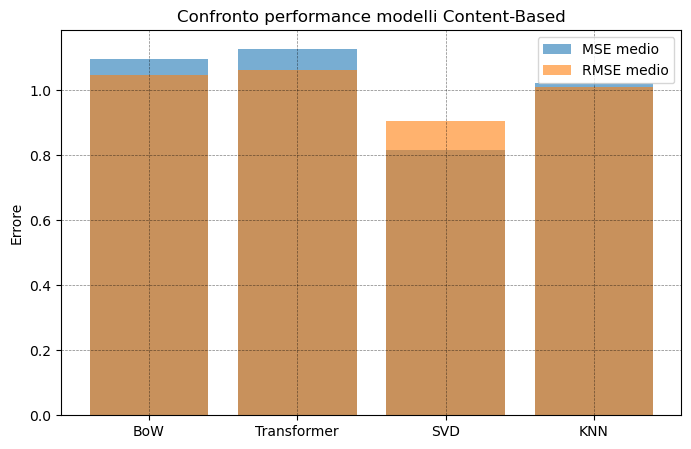

In [25]:
mse_KNN = 1.021
mse_SVD = 0.817
rmse_KNN = 1.010
rmse_SVD = 0.904

mse_means = [average_mse, average_mse_transformer, mse_SVD, mse_KNN]
rmse_means = [average_rmse, average_rmse_transformer, rmse_SVD, rmse_KNN]

labels = ['BoW', 'Transformer', 'SVD', 'KNN']
plt.figure(figsize=(8,5))
plt.bar(labels, mse_means, alpha=0.6, label='MSE medio')
plt.bar(labels, rmse_means, alpha=0.6, label='RMSE medio')
plt.title('Confronto performance modelli Content-Based')
plt.ylabel('Errore')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5, color='black', alpha=0.5)
plt.show()